# RealMLP XAI study notebook

This notebook is a model-specific XAI study for the saved 10-fold RealMLP checkpoint family reconstructed from `churn_analysis_helpers.py`.

The focus is not merely to replay predictions. The focus is to understand the model's smooth nonlinear response geometry, feature sensitivity, and where that geometry helps or fails.

## Study perspective

We treat the fitted predictor as an ensemble-averaged probability map:
$$
p_{\text{mlp}}(x) = \frac{1}{K}\sum_{k=1}^{K}\operatorname{softmax}\!\big(g_k(\phi_{\text{num}}(x_{\text{num}}), \phi_{\text{cat}}(x_{\text{cat}}))\big)_1.
$$

Unlike the tree model, the RealMLP combines:
- robust smooth-clipped numerical scaling,
- periodic numerical embeddings,
- one-hot and learnt categorical embeddings,
- stacked GELU,
- fold-model averaging.

The central questions are:

1. Which variables drive the ensemble's global behaviour?
2. Where is the response surface smooth, sharp, or unstable?
3. Which cases create member disagreement?
4. Which inputs move the model most under local perturbation or ablation?

## Required files in `./`

- `train.csv`
- `test.csv`
- `realmlp_fold_*.pth`
- `churn_analysis_helpers.py`


In [2]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.inspection import permutation_importance

from churn_analysis_helpers import (
    CFG,
    seed_everything,
    setup_plotting,
    ensure_output_dir,
    savefig,
    build_feature_frames,
    prepare_realmlp_frames,
    inspect_realmlp_schema,
    replay_realmlp,
    make_decile_frame,
    cumulative_capture,
    FE_realmlp,
    RobustScaleSmoothClipTransform,
    RealMLP,
    load_realmlp_checkpoints,
)
from sklearn.preprocessing import TargetEncoder

seed_everything(67)
setup_plotting()

cfg = CFG()
ensure_output_dir(cfg)

# Optional path overrides
# cfg.train_path = "./train.csv"
# cfg.test_path = "./test.csv"
# cfg.realmlp_pattern = "realmlp_fold_*.pth"
# cfg.output_dir = "./analysis_outputs_realmlp"


## 1. Reconstruct the exact RealMLP feature space

This section uses the helper file exactly as written to rebuild the numerical and categorical representations used by the saved checkpoints.


In [3]:
bundle = build_feature_frames(cfg)
realmlp_bundle = prepare_realmlp_frames(bundle)
schema = inspect_realmlp_schema(realmlp_bundle, cfg)

print("Numerical features:", schema["numeric_count"])
print("Categorical features:", schema["categorical_count"])
print("Target-encoded cats:", schema["target_encoded_cat_count"])
print("Augmented numeric dim:", schema["augmented_numeric_count"])
display(pd.Series(schema).to_frame("value"))


Numerical features: 22
Categorical features: 54
Target-encoded cats: 32
Augmented numeric dim: 54


,value
numeric_count,22
categorical_count,54
target_encoded_cat_count,32
augmented_numeric_count,54
NUMS,"[SeniorCitizen, tenure, MonthlyCharges, TotalC..."
CATEGORY,"[gender, Partner, Dependents, PhoneService, Mu..."


## 2. Replay the saved fold checkpoints

The helper already reconstructs the exact replay path. We use that first, then build additional XAI routines around the replayed pipeline.


In [8]:
replay = replay_realmlp(bundle, realmlp_bundle, cfg)

print("device:", replay["device"])
print("RealMLP OOF AUC:", f"{replay['realmlp_oof_auc']:.6f}")
print("RealMLP OOF log loss:", f"{log_loss(bundle['y'], replay['realmlp_oof']):.6f}")
print("RealMLP OOF Brier:", f"{brier_score_loss(bundle['y'], replay['realmlp_oof']):.6f}")

device: cpu
RealMLP OOF AUC: 0.917199
RealMLP OOF log loss: 0.298696
RealMLP OOF Brier: 0.095583


In [9]:
analysis_train = pd.DataFrame({
    cfg.id_col: bundle["train"][cfg.id_col].values,
    "y_true": bundle["y"],
    "realmlp_pred": replay["realmlp_oof"],
})

analysis_test = pd.DataFrame({
    cfg.id_col: bundle["test"][cfg.id_col].values,
    "realmlp_pred": replay["realmlp_test_mean"],
})

analysis_train["pred_rank_pct"] = analysis_train["realmlp_pred"].rank(pct=True, method="average")
analysis_train["hard_label"] = (analysis_train["realmlp_pred"] >= 0.5).astype(int)
analysis_train["error"] = analysis_train["y_true"] - analysis_train["realmlp_pred"]
analysis_train["abs_error"] = analysis_train["error"].abs()
analysis_train["case_type"] = np.select(
    [
        (analysis_train["y_true"] == 1) & (analysis_train["hard_label"] == 1),
        (analysis_train["y_true"] == 0) & (analysis_train["hard_label"] == 0),
        (analysis_train["y_true"] == 0) & (analysis_train["hard_label"] == 1),
        (analysis_train["y_true"] == 1) & (analysis_train["hard_label"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="other"
)
analysis_train["risk_band"] = pd.qcut(
    analysis_train["realmlp_pred"], q=5,
    labels=["very_low", "low", "mid", "high", "very_high"],
    duplicates="drop",
)

member_cols = [f"member_{i}" for i in range(1, replay["realmlp_test_members"].shape[1] + 1)]
test_member_df = pd.DataFrame(replay["realmlp_test_members"], columns=member_cols)
analysis_test = pd.concat([analysis_test, test_member_df], axis=1)
analysis_test["member_std"] = analysis_test[member_cols].std(axis=1)
analysis_test["member_range"] = analysis_test[member_cols].max(axis=1) - analysis_test[member_cols].min(axis=1)

analysis_train.head()


,id,y_true,realmlp_pred,pred_rank_pct,hard_label,error,abs_error,case_type,risk_band
0,0,0,0.009655,0.282337,0,-0.009655,0.009655,TN,low
1,1,0,0.002292,0.044788,0,-0.002292,0.002292,TN,very_low
2,2,0,0.301171,0.704309,0,-0.301171,0.301171,TN,high
3,3,1,0.707725,0.927854,1,0.292275,0.292275,TP,very_high
4,4,1,0.788549,0.960841,1,0.211451,0.211451,TP,very_high


## 3. Behavioural diagnostics

These plots answer whether the replayed ensemble:
- separates classes cleanly,
- calibrates sensibly,
- concentrates positives in the upper tail,
- produces tail overconfidence or underconfidence.


saved: analysis_outputs\realmlp_01_core_diagnostics.png


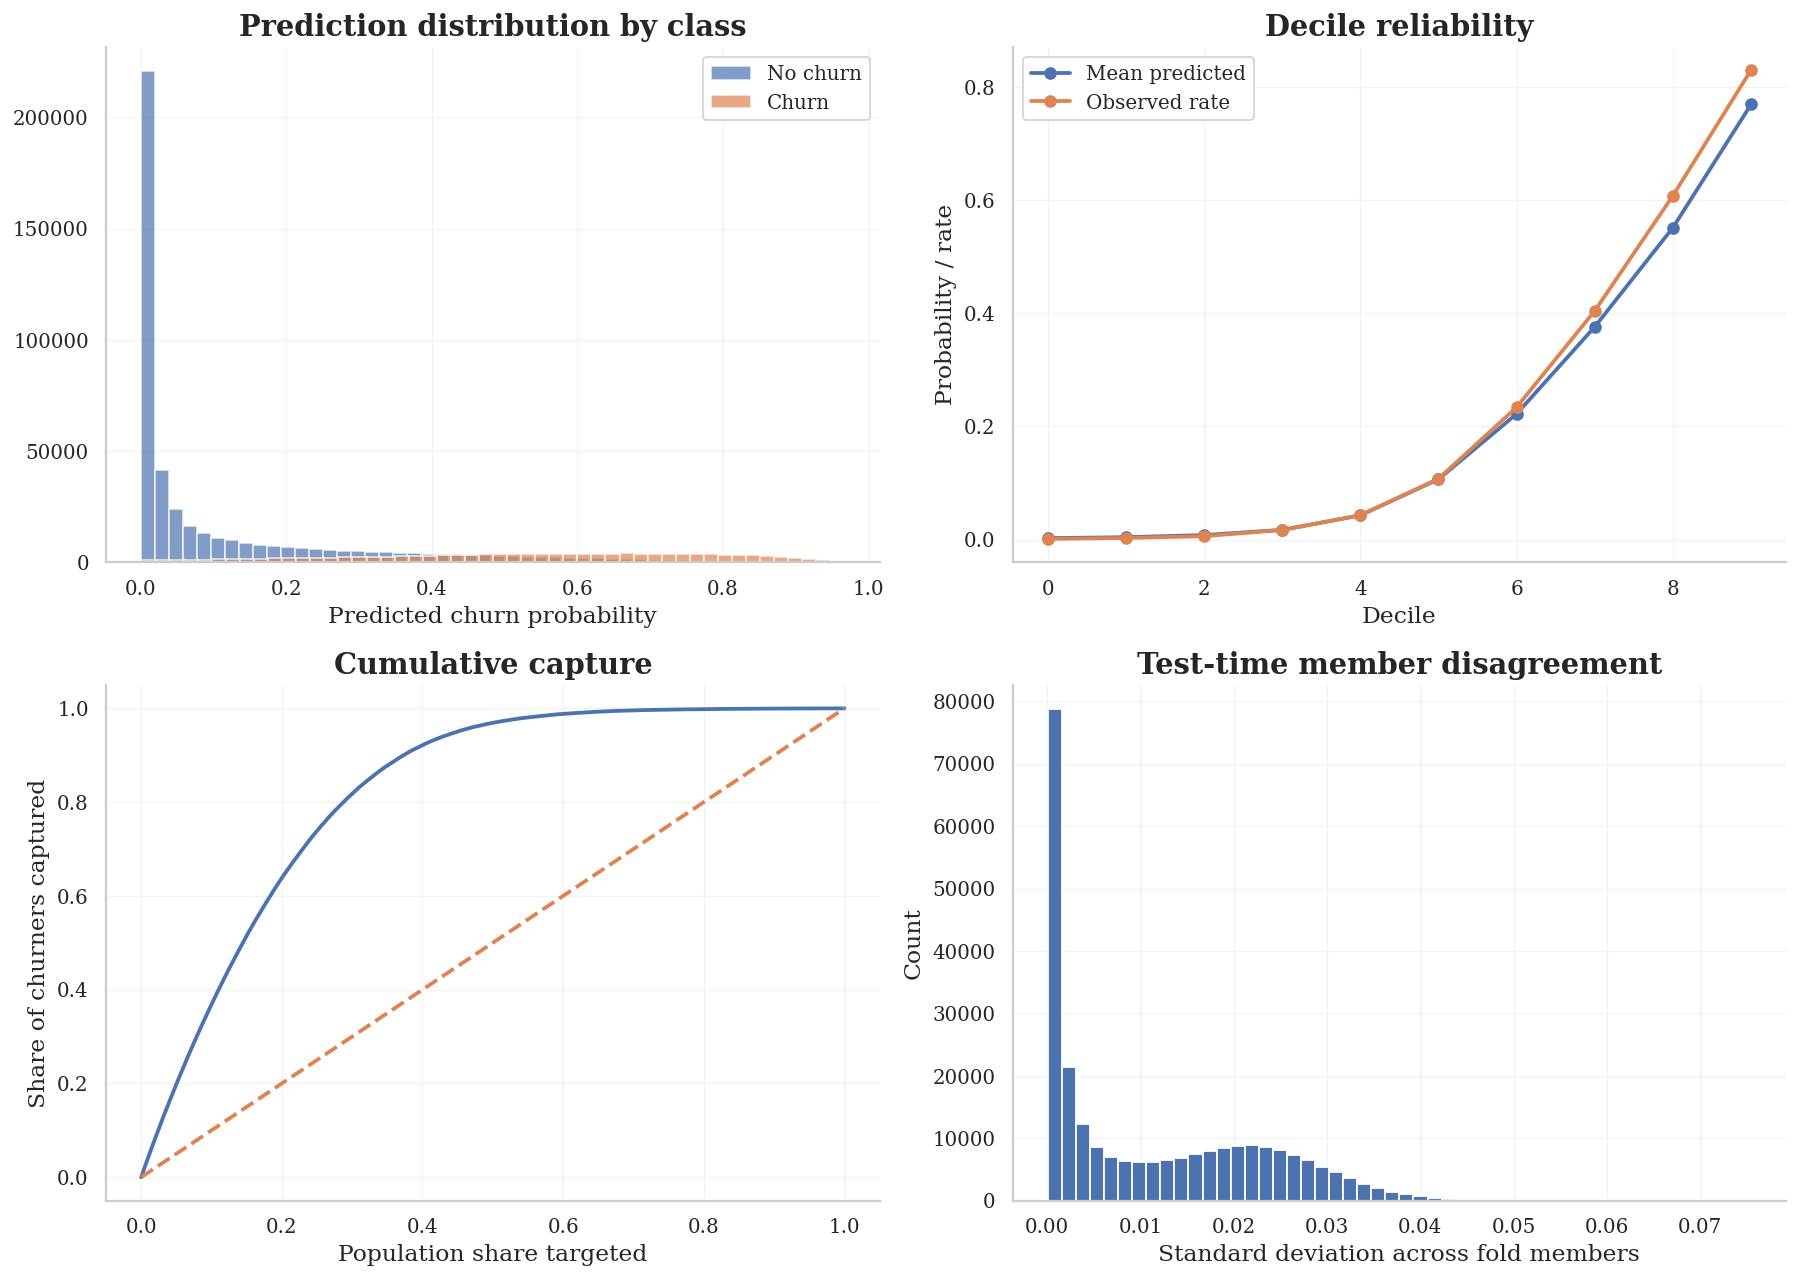

,bin,mean_pred,churn_rate,n,pred_min,pred_max
0,0,0.002330,0.001094,59420,0.000880,0.003107
1,1,0.004047,0.002710,59419,0.003107,0.005285
2,2,0.007776,0.005840,59419,0.005285,0.011012
3,3,0.017026,0.016829,59420,0.011013,0.025836
4,4,0.042658,0.042966,59419,0.025837,0.065962
5,5,0.106499,0.107390,59419,0.065962,0.156202
6,6,0.221997,0.233793,59420,0.156208,0.294355
7,7,0.375918,0.404180,59419,0.294356,0.460177
8,8,0.551160,0.607600,59419,0.460180,0.647994
9,9,0.768880,0.829670,59420,0.648000,0.966818


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(analysis_train.loc[analysis_train["y_true"] == 0, "realmlp_pred"], bins=50, alpha=0.7, label="No churn")
axes[0, 0].hist(analysis_train.loc[analysis_train["y_true"] == 1, "realmlp_pred"], bins=50, alpha=0.7, label="Churn")
axes[0, 0].set_title("Prediction distribution by class")
axes[0, 0].set_xlabel("Predicted churn probability")
axes[0, 0].legend()

dec_realmlp = make_decile_frame(bundle["y"], analysis_train["realmlp_pred"], n_bins=10)
axes[0, 1].plot(dec_realmlp["mean_pred"], marker="o", label="Mean predicted")
axes[0, 1].plot(dec_realmlp["churn_rate"], marker="o", label="Observed rate")
axes[0, 1].set_title("Decile reliability")
axes[0, 1].set_xlabel("Decile")
axes[0, 1].set_ylabel("Probability / rate")
axes[0, 1].legend()

cap_realmlp = cumulative_capture(bundle["y"], analysis_train["realmlp_pred"])
axes[1, 0].plot(cap_realmlp["population_share"], cap_realmlp["capture_rate"])
axes[1, 0].plot([0, 1], [0, 1], linestyle="--")
axes[1, 0].set_title("Cumulative capture")
axes[1, 0].set_xlabel("Population share targeted")
axes[1, 0].set_ylabel("Share of churners captured")

axes[1, 1].hist(analysis_test["member_std"], bins=50)
axes[1, 1].set_title("Test-time member disagreement")
axes[1, 1].set_xlabel("Standard deviation across fold members")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
savefig(cfg, "realmlp_01_core_diagnostics.png")
plt.show()

display(dec_realmlp)


## 4. Build reusable prediction functions for custom slices

The helper already provides replay for the original train/test split. For XAI work we also need predictions on modified input frames.

The next cell wraps the same preprocessing logic used by the helper so that we can:
- perturb rows,
- draw two-dimensional conditional slices,
- compute finite-difference sensitivities,
- run grouped ablations.

This cell does not modify the helper file. It only uses it as-is.


In [11]:
def prepare_custom_realmlp_df(raw_df, realmlp_bundle, cfg):
    df = raw_df.copy()
    if cfg.id_col in df.columns:
        df = df.drop(columns=[cfg.id_col]).copy()

    if cfg.target_col in df.columns:
        df[cfg.target_col] = (df[cfg.target_col] == "Yes").astype(int)

    df = FE_realmlp(df, cfg)

    for c in ["MonthlyCharges", "TotalCharges"]:
        for n_bins in ([100, 1000] if c == "MonthlyCharges" else [500, 4000]):
            kb = realmlp_bundle["kb_objects"][f"{c}_bin{n_bins}"]
            vals = df[c].values.reshape(-1, 1)
            df[f"{c}_bin{n_bins}"] = kb.transform(vals).flatten().astype(int)

    drop_cols = [c for c in realmlp_bundle["DROP"] if c in df.columns]
    df = df.drop(columns=drop_cols, errors="ignore")

    if "service_count" not in df.columns:
        from churn_analysis_helpers import REALMLP_SERVICE_COLS
        df["service_count"] = (df[REALMLP_SERVICE_COLS] == "Yes").sum(axis=1).astype("float32")

    category = realmlp_bundle["CATEGORY"]
    nums = realmlp_bundle["NUMS"]

    for c in category:
        if c not in df.columns:
            df[c] = "__missing__"
        mapping_info = realmlp_bundle["category_mappings"][c]
        mapping = mapping_info["mapping"]
        default = mapping_info["default"]
        df[c] = df[c].map(lambda x: mapping.get(x, default)).astype("int32")

    for c in nums:
        if c not in df.columns:
            df[c] = 0.0

    X_num = df[nums].values.astype(np.float32)
    X_cat = df[category].values.astype(np.int64)

    return df, X_num, X_cat


def build_realmlp_fold_cache(realmlp_bundle, cfg, embed_dim=10, n_ens=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_num = realmlp_bundle["X_num"]
    X_cat = realmlp_bundle["X_cat"]
    y_nn = realmlp_bundle["y_nn"]
    cat_dims_global = realmlp_bundle["cat_dims_global"]
    cols_to_encode = realmlp_bundle["cols_to_encode"]
    ckpts = load_realmlp_checkpoints(cfg)

    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.seed)

    cache = []
    for fold, ((train_idx, valid_idx), ckpt_path) in enumerate(zip(skf.split(X_num, y_nn), ckpts), start=1):
        X_num_train, X_cat_train, y_train = X_num[train_idx], X_cat[train_idx], y_nn[train_idx]

        te = TargetEncoder(target_type="binary", cv=5)
        if len(cols_to_encode) > 0:
            X_cat_train_encoded = te.fit_transform(X_cat_train[:, cols_to_encode], y_train)
        else:
            X_cat_train_encoded = np.zeros((len(train_idx), 0), dtype=np.float32)

        X_num_train_aug = np.concatenate([X_num_train, X_cat_train_encoded], axis=1)
        rssc = RobustScaleSmoothClipTransform().fit(X_num_train_aug)

        state = torch.load(ckpt_path, map_location=device)
        expected_n_num = int(state["num_embed.w1"].shape[1])

        model = RealMLP(
            input_dim=int(expected_n_num * 5 + sum([c if c <= 8 else embed_dim for c in cat_dims_global])),
            output_dim=2,
            cat_dims=cat_dims_global,
            n_numerical=expected_n_num,
            n_ens=n_ens,
            embed_dim=embed_dim,
            device=device,
        ).to(device)
        model.load_state_dict(state)
        model.eval()

        cache.append({
            "fold": fold,
            "train_idx": train_idx,
            "valid_idx": valid_idx,
            "te": te,
            "rssc": rssc,
            "model": model,
            "device": device,
        })
    return cache


def predict_realmlp_custom(raw_df, realmlp_bundle, cfg, fold_cache, eval_bs=8192):
    _, X_num_custom, X_cat_custom = prepare_custom_realmlp_df(raw_df, realmlp_bundle, cfg)
    cols_to_encode = realmlp_bundle["cols_to_encode"]

    preds = []
    member_preds = []
    for item in fold_cache:
        te = item["te"]
        rssc = item["rssc"]
        model = item["model"]
        device = item["device"]

        if len(cols_to_encode) > 0:
            X_cat_encoded = te.transform(X_cat_custom[:, cols_to_encode])
        else:
            X_cat_encoded = np.zeros((len(X_num_custom), 0), dtype=np.float32)

        X_num_aug = np.concatenate([X_num_custom, X_cat_encoded], axis=1)
        X_num_aug = rssc.transform(X_num_aug)

        X_num_t = torch.as_tensor(X_num_aug, dtype=torch.float32, device=device)
        X_cat_t = torch.as_tensor(X_cat_custom, dtype=torch.long, device=device)

        fold_probs = []
        with torch.no_grad():
            for start in range(0, len(raw_df), eval_bs):
                probs = model(X_num_t[start:start + eval_bs], X_cat_t[start:start + eval_bs]).mean(dim=1)[:, 1]
                fold_probs.append(probs.detach().cpu().numpy())
        fold_probs = np.concatenate(fold_probs, axis=0)
        preds.append(fold_probs)

        # Member-level predictions from the ensemble dimension
        with torch.no_grad():
            member_block = []
            for start in range(0, len(raw_df), eval_bs):
                prob_full = model(X_num_t[start:start + eval_bs], X_cat_t[start:start + eval_bs])[:, :, 1]
                member_block.append(prob_full.detach().cpu().numpy())
        member_block = np.concatenate(member_block, axis=0)
        member_preds.append(member_block)

    preds = np.vstack(preds)
    mean_pred = preds.mean(axis=0)

    member_preds = np.stack(member_preds, axis=0)   # fold x row x member
    flat_member_preds = member_preds.transpose(1, 0, 2).reshape(len(raw_df), -1)

    return {
        "mean_pred": mean_pred,
        "fold_pred_matrix": preds,
        "member_pred_matrix": flat_member_preds,
        "custom_X_num": X_num_custom,
        "custom_X_cat": X_cat_custom,
    }


fold_cache = build_realmlp_fold_cache(realmlp_bundle, cfg)
print("Cached folds:", len(fold_cache))


Cached folds: 10


In [14]:
def normalise_realmlp_fold_cache(fold_cache):
    normalised = []

    for i, fold_obj in enumerate(fold_cache):
        keys = set(fold_obj.keys())

        model = None
        target_encoder = None
        rssc = None

        for k in ["model", "net", "estimator"]:
            if k in fold_obj:
                model = fold_obj[k]
                break

        for k in ["target_encoder", "te", "target_enc", "encoder"]:
            if k in fold_obj:
                target_encoder = fold_obj[k]
                break

        for k in ["rssc", "scaler", "transform", "num_transform"]:
            if k in fold_obj:
                rssc = fold_obj[k]
                break

        if model is None:
            raise KeyError(
                f"Fold cache entry {i} is missing a model-like key. Found keys: {sorted(keys)}"
            )
        if target_encoder is None:
            raise KeyError(
                f"Fold cache entry {i} is missing a target-encoder-like key. Found keys: {sorted(keys)}"
            )
        if rssc is None:
            raise KeyError(
                f"Fold cache entry {i} is missing an rssc/scaler-like key. Found keys: {sorted(keys)}"
            )

        normalised.append({
            "model": model,
            "target_encoder": target_encoder,
            "rssc": rssc,
        })

    return normalised


fold_cache = normalise_realmlp_fold_cache(fold_cache)
print(fold_cache[0].keys())

dict_keys(['model', 'target_encoder', 'rssc'])


## 5. Permutation importance on the replayed competition train set

For the neural model, permutation importance is a robust first-line global explanation because it does not require a tree-specific decomposition and respects the actual fitted predictor.

  1/22  SeniorCitizen                   AUC drop = 0.001306
  2/22  tenure                          AUC drop = 0.000053
  3/22  MonthlyCharges                  AUC drop = 0.000202
  4/22  TotalCharges                    AUC drop = 0.000198
  5/22  tenure_digit0                   AUC drop = 0.000022
  6/22  tenure_digit1                   AUC drop = 0.000319
  7/22  MonthlyCharges_digit-2          AUC drop = 0.000012
  8/22  MonthlyCharges_digit-1          AUC drop = 0.000013
  9/22  MonthlyCharges_digit0           AUC drop = 0.000009
 10/22  MonthlyCharges_digit1           AUC drop = 0.000029
 11/22  MonthlyCharges_digit2           AUC drop = 0.000066
 12/22  TotalCharges_digit-2            AUC drop = 0.000010
 13/22  TotalCharges_digit-1            AUC drop = 0.000013
 14/22  TotalCharges_digit0             AUC drop = 0.000014
 15/22  TotalCharges_digit1             AUC drop = 0.000045
 16/22  TotalCharges_digit2             AUC drop = 0.000185
 17/22  TotalCharges_digit3             

,feature,baseline_auc,perm_auc_mean,perm_auc_std,mean_importance,std_importance
0,x2,0.918749,0.913101,1.381999e-04,0.005648,1.381999e-04
1,SeniorCitizen,0.918749,0.917442,3.250889e-05,0.001306,3.250889e-05
2,x1_0,0.918749,0.917763,9.978155e-06,0.000986,9.978155e-06
3,x3,0.918749,0.918219,9.073667e-06,0.000530,9.073667e-06
4,tenure_digit1,0.918749,0.918430,4.806324e-05,0.000319,4.806324e-05
5,MonthlyCharges,0.918749,0.918547,1.387151e-05,0.000202,1.387151e-05
6,TotalCharges,0.918749,0.918551,1.026089e-05,0.000198,1.026089e-05
7,TotalCharges_digit2,0.918749,0.918564,1.885185e-05,0.000185,1.885185e-05
8,MonthlyCharges_digit2,0.918749,0.918683,1.561111e-05,0.000066,1.561111e-05
9,TotalCharges_digit3,0.918749,0.918694,9.975575e-06,0.000055,9.975575e-06


saved: analysis_outputs\realmlp_02_permutation_importance.png


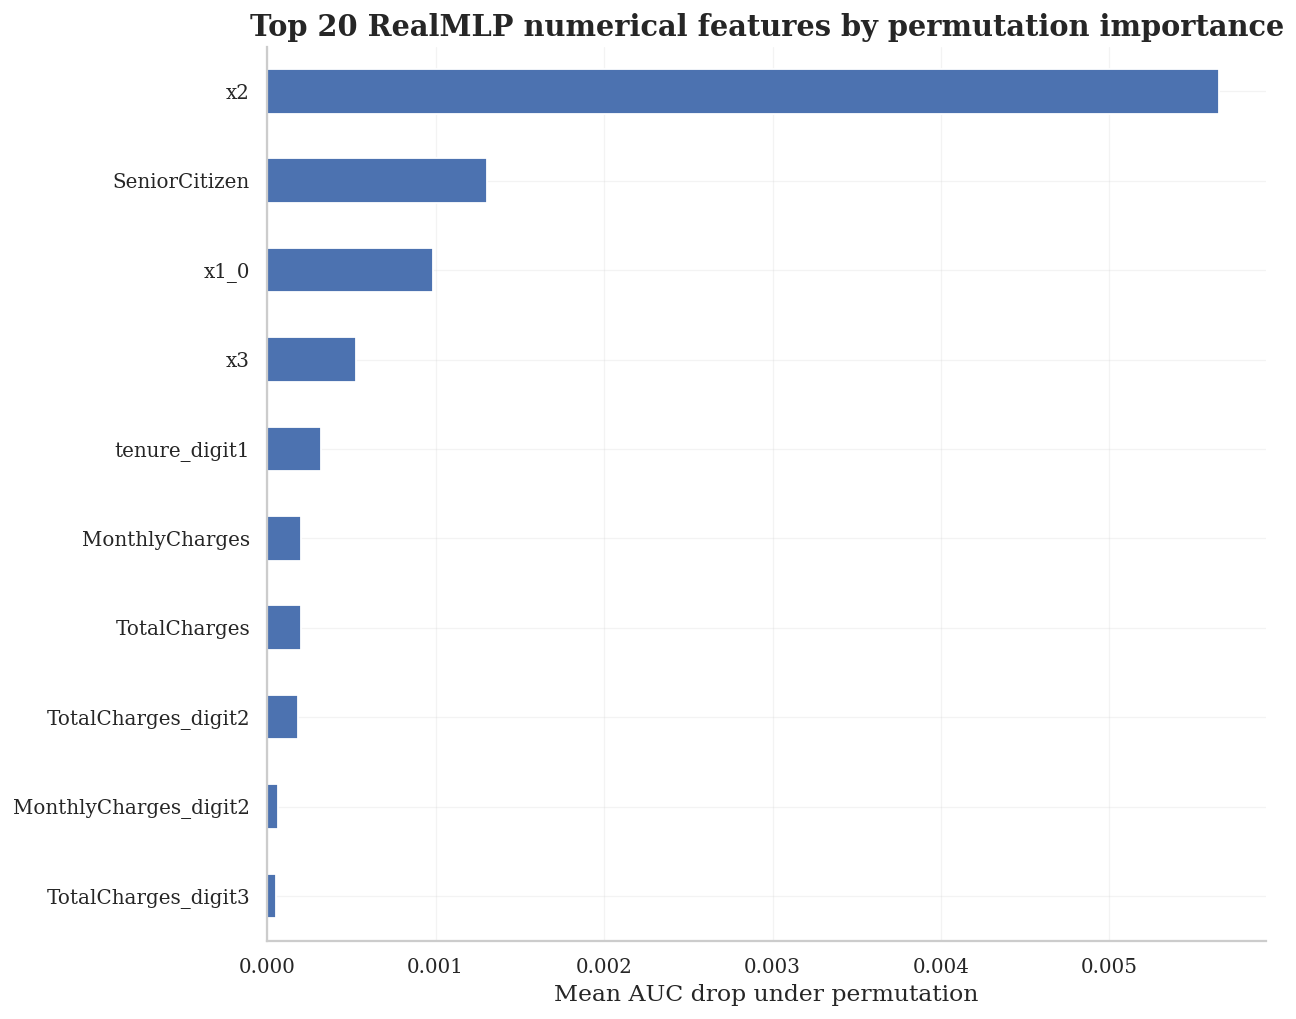

In [33]:
from sklearn.metrics import roc_auc_score

def _fold_get(fold_obj, *names):
    for name in names:
        if name in fold_obj:
            return fold_obj[name]
    raise KeyError(f"None of {names} found in fold cache keys: {sorted(fold_obj.keys())}")


def _build_realmlp_cached_fold_inputs(
    realmlp_bundle,
    fold_cache,
    row_idx=None,
):
    X_num = realmlp_bundle["X_num"].astype(np.float32)
    X_cat = realmlp_bundle["X_cat"].astype(np.int64)
    y = realmlp_bundle["y_nn"]
    cols_to_encode = realmlp_bundle["cols_to_encode"]

    if row_idx is None:
        row_idx = np.arange(X_num.shape[0])

    X_num = X_num[row_idx].copy()
    X_cat = X_cat[row_idx].copy()
    y = y[row_idx].copy()

    cached = []
    for fold_obj in fold_cache:
        te = _fold_get(fold_obj, "target_encoder", "te", "target_enc", "encoder")
        rssc = _fold_get(fold_obj, "rssc", "scaler", "transform", "num_transform")
        model = _fold_get(fold_obj, "model", "net", "estimator")

        if len(cols_to_encode) > 0:
            X_cat_encoded = te.transform(X_cat[:, cols_to_encode]).astype(np.float32)
        else:
            X_cat_encoded = np.zeros((X_num.shape[0], 0), dtype=np.float32)

        X_num_aug = np.concatenate([X_num, X_cat_encoded], axis=1).astype(np.float32)
        X_num_aug = rssc.transform(X_num_aug).astype(np.float32)

        cached.append({
            "model": model,
            "X_num_aug": X_num_aug,
            "X_cat": X_cat,
        })

    return cached, y, row_idx


def _predict_realmlp_from_cached(
    cached_fold_inputs,
    eval_bs=32768,
):
    all_fold_preds = []

    for fold_obj in cached_fold_inputs:
        model = fold_obj["model"]
        X_num_aug = fold_obj["X_num_aug"]
        X_cat = fold_obj["X_cat"]

        device = next(model.parameters()).device

        X_num_t = torch.as_tensor(X_num_aug, dtype=torch.float32, device=device)
        X_cat_t = torch.as_tensor(X_cat, dtype=torch.long, device=device)

        preds = []
        model.eval()
        with torch.no_grad():
            for start in range(0, X_num_t.shape[0], eval_bs):
                batch_num = X_num_t[start:start + eval_bs]
                batch_cat = X_cat_t[start:start + eval_bs]
                probs = model(batch_num, batch_cat).mean(dim=1)[:, 1]
                preds.append(probs.detach().cpu().numpy())

        all_fold_preds.append(np.concatenate(preds, axis=0))

    all_fold_preds = np.column_stack(all_fold_preds)
    mean_pred = all_fold_preds.mean(axis=1)
    std_pred = all_fold_preds.std(axis=1)

    return {
        "member_preds": all_fold_preds,
        "mean_pred": mean_pred,
        "std_pred": std_pred,
    }


def realmlp_numeric_permutation_importance_fast(
    realmlp_bundle,
    fold_cache,
    n_repeats=2,
    sample_n=120_000,
    random_state=67,
    eval_bs=32768,
):
    X_num_full = realmlp_bundle["X_num"]
    feature_names = list(realmlp_bundle["NUMS"])
    rng = np.random.RandomState(random_state)

    if sample_n is not None and sample_n < X_num_full.shape[0]:
        row_idx = rng.choice(X_num_full.shape[0], size=sample_n, replace=False)
        row_idx = np.sort(row_idx)
    else:
        row_idx = np.arange(X_num_full.shape[0])

    cached_fold_inputs, y, row_idx = _build_realmlp_cached_fold_inputs(
        realmlp_bundle=realmlp_bundle,
        fold_cache=fold_cache,
        row_idx=row_idx,
    )

    baseline = _predict_realmlp_from_cached(
        cached_fold_inputs,
        eval_bs=eval_bs,
    )["mean_pred"]
    baseline_auc = roc_auc_score(y, baseline)

    # number of original numerical features before target-encoded columns are appended
    n_model_num_features = realmlp_bundle["X_num"].shape[1]

    rows = []
    for j, feat in enumerate(feature_names):
        aucs = []

        for _ in range(n_repeats):
            perm_idx = rng.permutation(len(y))

            permuted_cached = []
            for fold_obj in cached_fold_inputs:
                X_num_aug_perm = fold_obj["X_num_aug"].copy()
                # permute only the original numerical column j; keep encoded cols fixed
                X_num_aug_perm[:, j] = X_num_aug_perm[perm_idx, j]

                permuted_cached.append({
                    "model": fold_obj["model"],
                    "X_num_aug": X_num_aug_perm,
                    "X_cat": fold_obj["X_cat"],
                })

            pred_perm = _predict_realmlp_from_cached(
                permuted_cached,
                eval_bs=eval_bs,
            )["mean_pred"]

            aucs.append(roc_auc_score(y, pred_perm))

        aucs = np.asarray(aucs, dtype=float)
        rows.append({
            "feature": feat,
            "baseline_auc": baseline_auc,
            "perm_auc_mean": aucs.mean(),
            "perm_auc_std": aucs.std(ddof=0),
            "mean_importance": baseline_auc - aucs.mean(),
            "std_importance": aucs.std(ddof=0),
        })

        print(
            f"{j+1:>3d}/{len(feature_names)}  {feat:<30s}  "
            f"AUC drop = {baseline_auc - aucs.mean():.6f}"
        )

    out = (
        pd.DataFrame(rows)
        .sort_values("mean_importance", ascending=False)
        .reset_index(drop=True)
    )
    return out, baseline_auc, row_idx


perm_imp, baseline_auc, row_idx = realmlp_numeric_permutation_importance_fast(
    realmlp_bundle=realmlp_bundle,
    fold_cache=fold_cache,
    n_repeats=2,          # was 5
    sample_n=120_000,     # set None for full data
    random_state=cfg.seed,
    eval_bs=32768,        # larger batches = faster if memory allows
)

print(f"Baseline sampled OOF AUC from cached replay path: {baseline_auc:.6f}")
print(f"Rows used: {len(row_idx):,}")
display(perm_imp.head(25))

ax = perm_imp.head(10).sort_values("mean_importance").plot(
    x="feature",
    y="mean_importance",
    kind="barh",
    legend=False,
    figsize=(10, 8),
)
ax.set_title("Top 20 RealMLP numerical features by permutation importance")
ax.set_xlabel("Mean AUC drop under permutation")
ax.set_ylabel("")
savefig(cfg, "realmlp_02_permutation_importance.png")
plt.show()

In [20]:
raw_train_no_id = realmlp_bundle["train_nn"].drop(columns=[cfg.id_col], errors="ignore").copy()

## 6. Local finite-difference sensitivity

We approximate local sensitivity of the probability surface with finite differences:
$$
S_j(x) \approx \frac{p(x + h e_j) - p(x - h e_j)}{2h}.
$$

This is not a gradient through the full preprocessing graph. It is a practical response derivative on the reconstructed end-to-end predictor.


 1/20  SeniorCitizen                   |mean sens| = 0.022135
 2/20  tenure                          |mean sens| = 0.000223
 3/20  MonthlyCharges                  |mean sens| = 0.000229
 4/20  TotalCharges                    |mean sens| = 0.000003
 5/20  tenure_digit0                   |mean sens| = 0.000140
 6/20  tenure_digit1                   |mean sens| = 0.002566
 7/20  MonthlyCharges_digit-2          |mean sens| = 0.000292
 8/20  MonthlyCharges_digit-1          |mean sens| = 0.000427
 9/20  MonthlyCharges_digit0           |mean sens| = 0.000200
10/20  MonthlyCharges_digit1           |mean sens| = 0.000220
11/20  MonthlyCharges_digit2           |mean sens| = 0.003959
12/20  TotalCharges_digit-2            |mean sens| = 0.000306
13/20  TotalCharges_digit-1            |mean sens| = 0.000342
14/20  TotalCharges_digit0             |mean sens| = 0.000290
15/20  TotalCharges_digit1             |mean sens| = 0.000673
16/20  TotalCharges_digit2             |mean sens| = 0.001161
17/20  T

,feature,mean_abs_sensitivity,mean_signed_sensitivity,step,base_pred_mean
0,x1_0,0.109892,0.063291,0.016422,0.245557
1,SeniorCitizen,0.022135,0.022135,0.015603,0.245557
2,MonthlyCharges_digit2,0.003959,0.003959,0.017033,0.245557
3,tenure_digit1,0.002566,-0.002566,0.118060,0.245557
4,x2,0.001274,0.001268,1.907246,0.245557
5,TotalCharges_digit2,0.001161,-0.001143,0.144354,0.245557
6,TotalCharges_digit3,0.000694,-0.000433,0.113957,0.245557
7,TotalCharges_digit1,0.000673,0.000463,0.138634,0.245557
8,MonthlyCharges_digit-1,0.000427,0.000064,0.140445,0.245557
9,TotalCharges_digit-1,0.000342,-0.000215,0.143612,0.245557


saved: analysis_outputs\realmlp_03_finite_difference_sensitivity.png


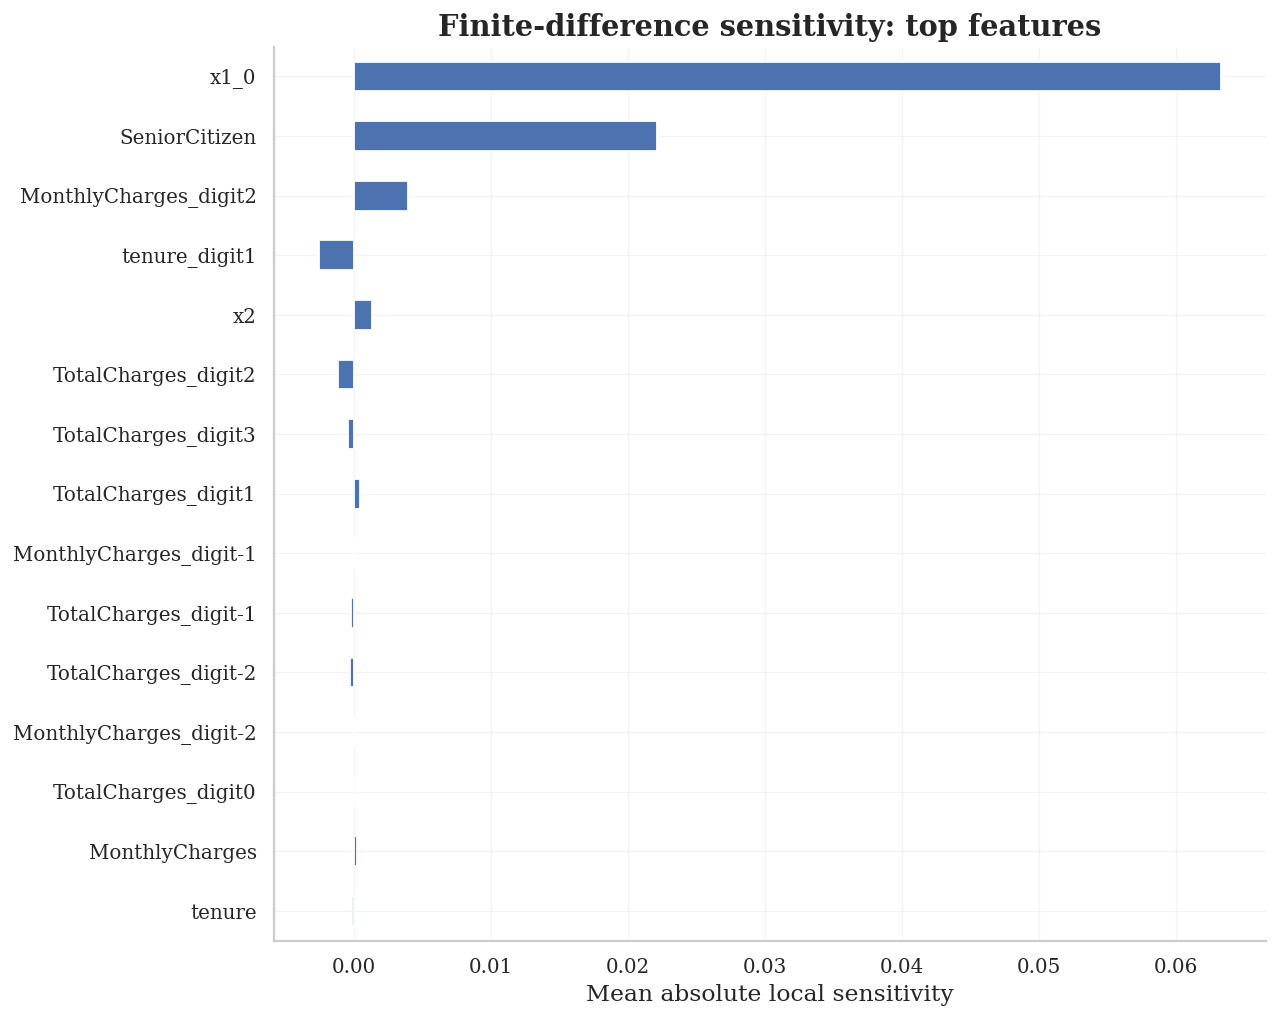

In [24]:
def finite_difference_sensitivity_arrays(
    realmlp_bundle,
    fold_cache,
    features,
    n_rows=1500,
    row_idx=None,
    eval_bs=32768,
):
    X_num_full = realmlp_bundle["X_num"].astype(np.float32)
    X_cat_full = realmlp_bundle["X_cat"].astype(np.int64)
    feature_names = list(realmlp_bundle["NUMS"])

    feat_to_idx = {f: i for i, f in enumerate(feature_names)}
    valid_features = [f for f in features if f in feat_to_idx]

    if row_idx is None:
        row_idx = np.arange(min(n_rows, X_num_full.shape[0]))
    else:
        row_idx = np.asarray(row_idx)[:n_rows]

    X_num = X_num_full[row_idx].copy()
    X_cat = X_cat_full[row_idx].copy()

    base_out = predict_realmlp_from_arrays(
        X_num, X_cat, realmlp_bundle, fold_cache, eval_bs=eval_bs
    )
    base_pred = base_out["mean_pred"]

    rows = []
    for feat in valid_features:
        j = feat_to_idx[feat]
        col = X_num[:, j].astype(np.float64)

        sd = float(np.std(col, ddof=0))
        step = max(sd * 0.05, 1e-3)

        X_num_plus = X_num.copy()
        X_num_minus = X_num.copy()
        X_num_plus[:, j] = X_num_plus[:, j] + step
        X_num_minus[:, j] = X_num_minus[:, j] - step

        plus_pred = predict_realmlp_from_arrays(
            X_num_plus, X_cat, realmlp_bundle, fold_cache, eval_bs=eval_bs
        )["mean_pred"]
        minus_pred = predict_realmlp_from_arrays(
            X_num_minus, X_cat, realmlp_bundle, fold_cache, eval_bs=eval_bs
        )["mean_pred"]

        sens = (plus_pred - minus_pred) / (2.0 * step)

        rows.append({
            "feature": feat,
            "mean_abs_sensitivity": float(np.mean(np.abs(sens))),
            "mean_signed_sensitivity": float(np.mean(sens)),
            "step": float(step),
            "base_pred_mean": float(np.mean(base_pred)),
        })

        print(
            f"{len(rows):>2d}/{len(valid_features)}  {feat:<30s}  "
            f"|mean sens| = {np.mean(np.abs(sens)):.6f}"
        )

    return pd.DataFrame(rows).sort_values("mean_abs_sensitivity", ascending=False).reset_index(drop=True)


numeric_candidates = list(realmlp_bundle["NUMS"])[:20]

sens_df = finite_difference_sensitivity_arrays(
    realmlp_bundle=realmlp_bundle,
    fold_cache=fold_cache,
    features=numeric_candidates,
    n_rows=1500,
    eval_bs=32768,
)

display(sens_df.head(20))

ax = sens_df.head(15).sort_values("mean_abs_sensitivity").plot(
    x="feature",
    y="mean_signed_sensitivity",
    kind="barh",
    legend=False,
    figsize=(10, 8),
)
ax.set_title("Finite-difference sensitivity: top features")
ax.set_xlabel("Mean absolute local sensitivity")
ax.set_ylabel("")
savefig(cfg, "realmlp_03_finite_difference_sensitivity.png")
plt.show()

## 7. Grouped categorical ablation

For the categorical branch we use grouped ablations. A group is neutralised by setting its columns to a reference category profile and measuring the induced probability shift.

This directly answers which categorical families the neural model is leaning on most.

contract_payment      |Δ| = 0.027666
internet_support      |Δ| = 0.024606
streaming_phone       |Δ| = 0.035071
household             |Δ| = 0.005301


,group,mean_abs_delta,mean_signed_delta,max_abs_delta
2,streaming_phone,0.035071,0.034967,0.223998
0,contract_payment,0.027666,-0.027666,0.198302
1,internet_support,0.024606,-0.024606,0.317824
3,household,0.005301,-0.004702,0.110057


saved: analysis_outputs\realmlp_04_grouped_ablation.png


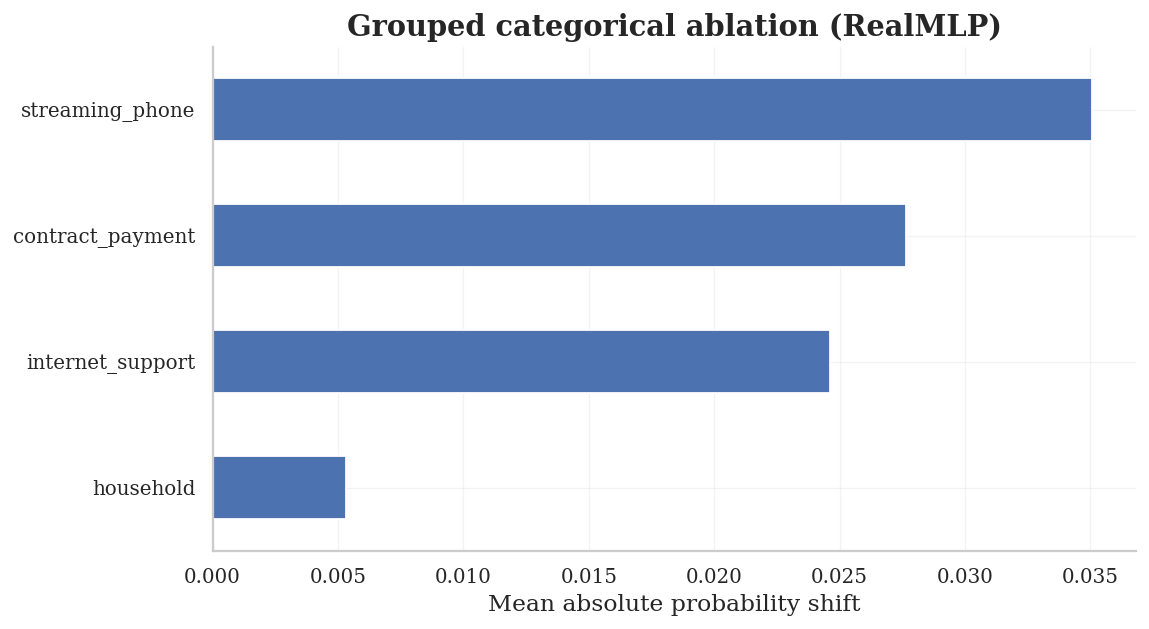

In [25]:
def categorical_group_ablation_arrays(
    realmlp_bundle,
    fold_cache,
    cat_groups,
    n_rows=3000,
    eval_bs=32768,
):
    X_num_full = realmlp_bundle["X_num"].astype(np.float32)
    X_cat_full = realmlp_bundle["X_cat"].astype(np.int64)
    y = realmlp_bundle["y_nn"]

    CATEGORY = realmlp_bundle["CATEGORY"]

    cat_to_idx = {c: i for i, c in enumerate(CATEGORY)}

    row_idx = np.arange(min(n_rows, X_num_full.shape[0]))
    X_num = X_num_full[row_idx].copy()
    X_cat = X_cat_full[row_idx].copy()

    base_pred = predict_realmlp_from_arrays(
        X_num, X_cat, realmlp_bundle, fold_cache, eval_bs=eval_bs
    )["mean_pred"]

    ablation_rows = []

    for group_name, cols in cat_groups.items():
        idxs = [cat_to_idx[c] for c in cols if c in cat_to_idx]
        if not idxs:
            continue

        X_cat_abl = X_cat.copy()

        # replace with most frequent category (mode in encoded space)
        for j in idxs:
            values, counts = np.unique(X_cat[:, j], return_counts=True)
            mode_val = values[np.argmax(counts)]
            X_cat_abl[:, j] = mode_val

        abl_pred = predict_realmlp_from_arrays(
            X_num, X_cat_abl, realmlp_bundle, fold_cache, eval_bs=eval_bs
        )["mean_pred"]

        delta = base_pred - abl_pred

        ablation_rows.append({
            "group": group_name,
            "mean_abs_delta": float(np.mean(np.abs(delta))),
            "mean_signed_delta": float(np.mean(delta)),
            "max_abs_delta": float(np.max(np.abs(delta))),
        })

        print(
            f"{group_name:<20s}  |Δ| = {np.mean(np.abs(delta)):.6f}"
        )

    return pd.DataFrame(ablation_rows).sort_values("mean_abs_delta", ascending=False)


cat_groups = {
    "contract_payment": ["Contract", "PaymentMethod", "PaperlessBilling"],
    "internet_support": ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"],
    "streaming_phone": ["PhoneService", "MultipleLines", "StreamingTV", "StreamingMovies"],
    "household": ["gender", "SeniorCitizen", "Partner", "Dependents"],
}

ablation_df = categorical_group_ablation_arrays(
    realmlp_bundle=realmlp_bundle,
    fold_cache=fold_cache,
    cat_groups=cat_groups,
    n_rows=3000,
    eval_bs=32768,
)

display(ablation_df)

ax = ablation_df.sort_values("mean_abs_delta").plot(
    x="group",
    y="mean_abs_delta",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Grouped categorical ablation (RealMLP)")
ax.set_xlabel("Mean absolute probability shift")
ax.set_ylabel("")
savefig(cfg, "realmlp_04_grouped_ablation.png")
plt.show()

## 8. Conditional decision surfaces

For selected numerical feature pairs, we visualise two-dimensional conditional slices:
$$
(x_i, x_j) \mapsto p_{\text{mlp}}(x_i, x_j, \tilde{x}_{-ij}).
$$

Compared with the tree model, these surfaces should be smoother and more curved if the neural representation is interpolating rather than thresholding.


saved: analysis_outputs\realmlp_surface_tenure_MonthlyCharges.png


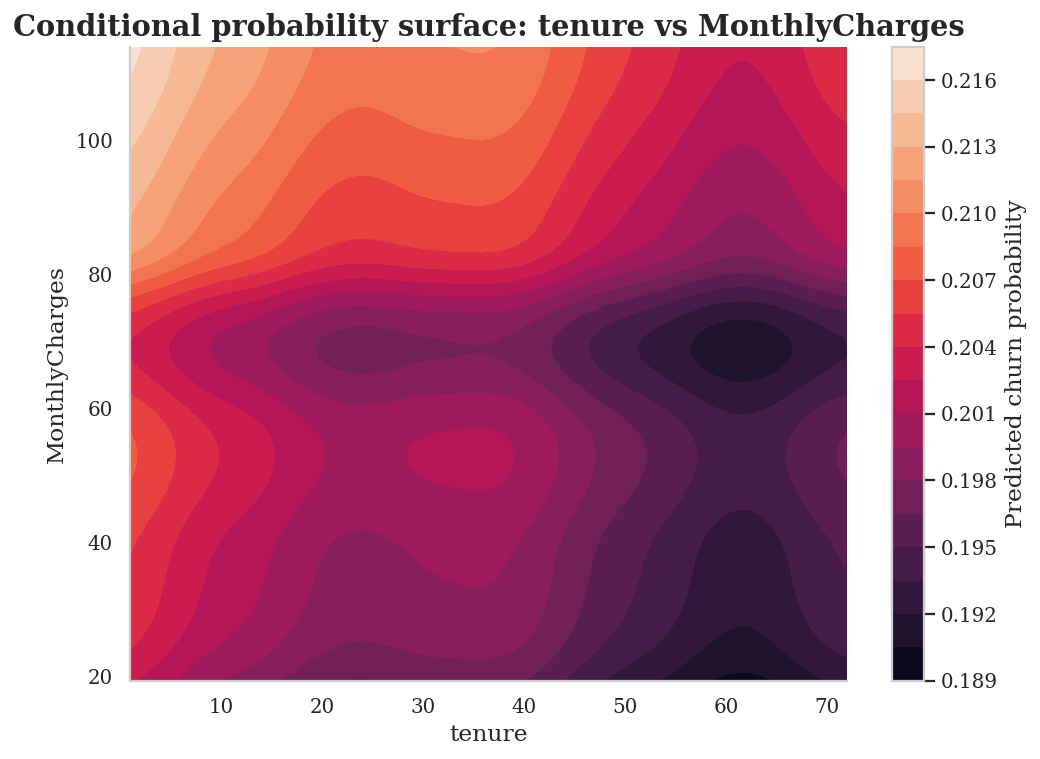

saved: analysis_outputs\realmlp_surface_MonthlyCharges_TotalCharges.png


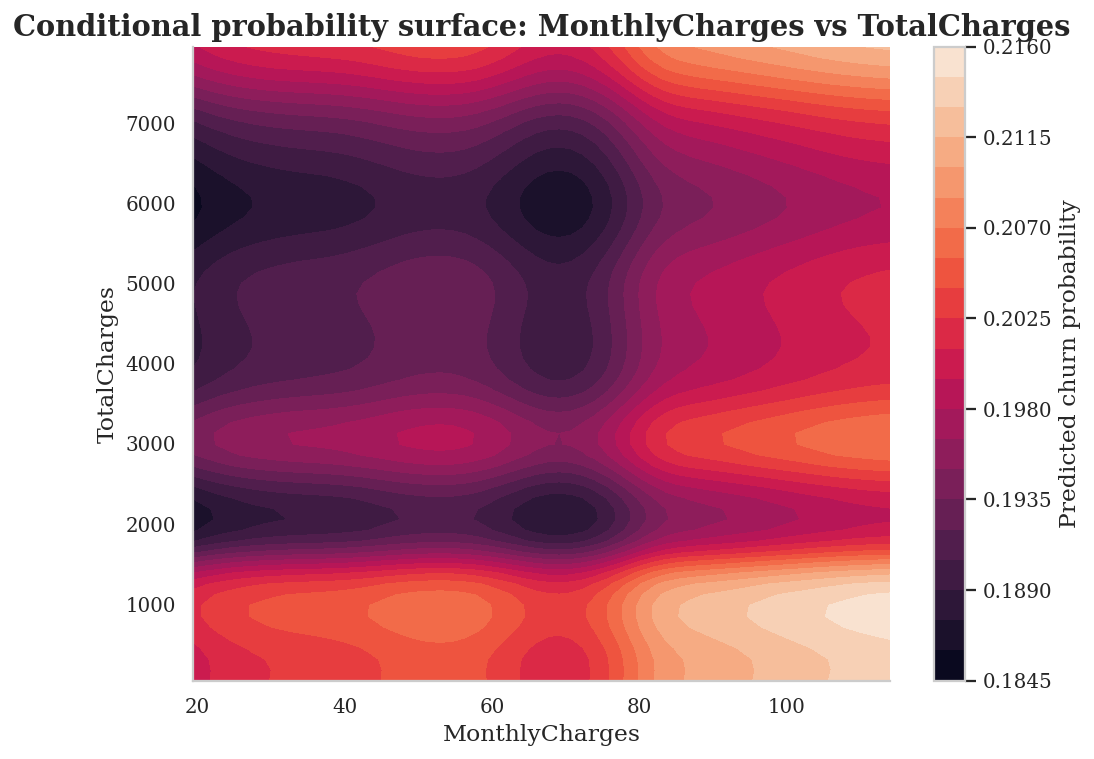

saved: analysis_outputs\realmlp_surface_tenure_x2.png


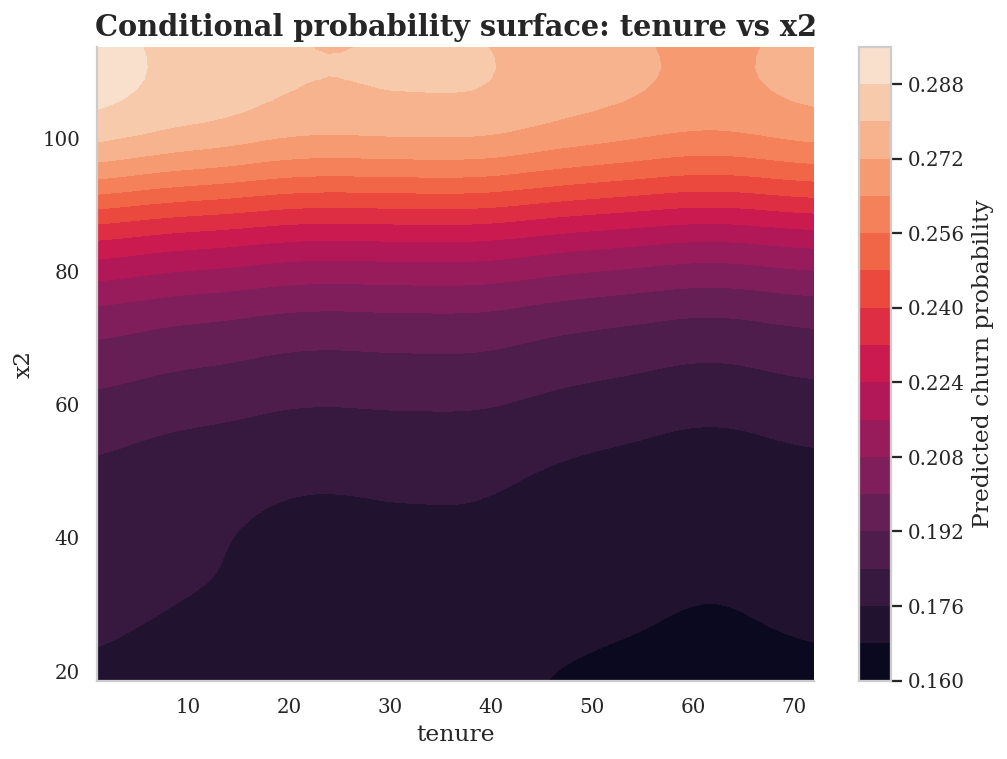

saved: analysis_outputs\realmlp_surface_x1_0_x2.png


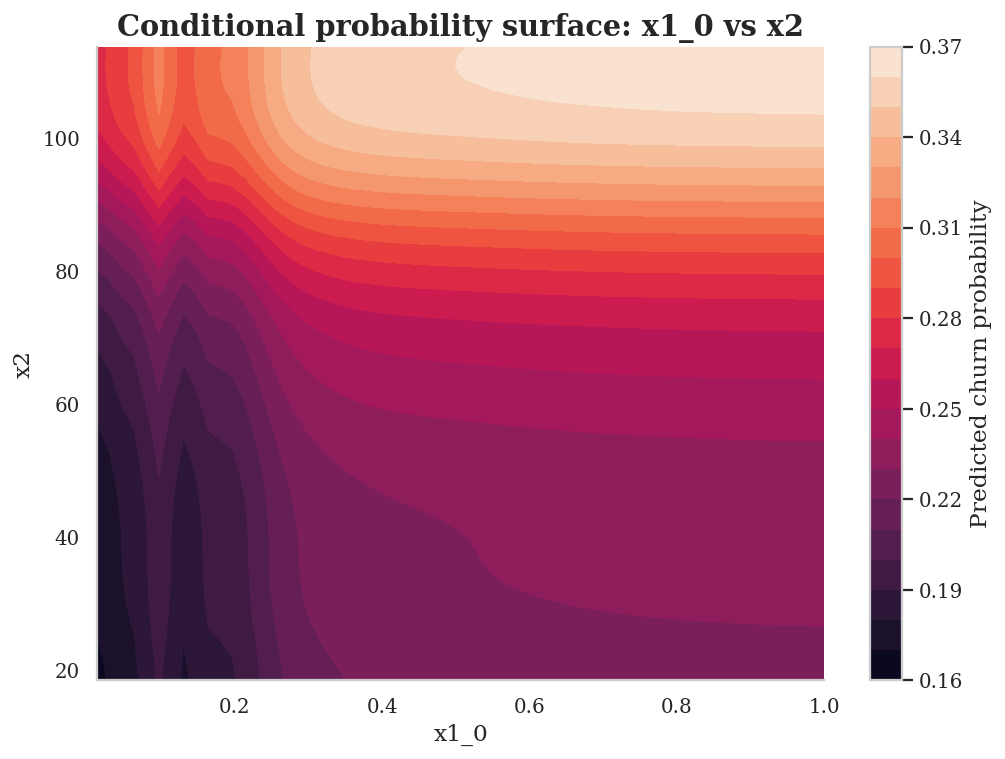

In [28]:
def plot_realmlp_surface_arrays(
    realmlp_bundle,
    fold_cache,
    feature_x,
    feature_y,
    grid_n=60,
    q_low=0.02,
    q_high=0.98,
    eval_bs=32768,
):
    feature_names = list(realmlp_bundle["NUMS"])
    feat_to_idx = {f: i for i, f in enumerate(feature_names)}

    if feature_x not in feat_to_idx or feature_y not in feat_to_idx:
        raise KeyError(
            f"Both features must be in realmlp_bundle['NUMS']. "
            f"Missing: {[f for f in [feature_x, feature_y] if f not in feat_to_idx]}"
        )

    X_num_full = realmlp_bundle["X_num"].astype(np.float32)
    X_cat_full = realmlp_bundle["X_cat"].astype(np.int64)

    jx = feat_to_idx[feature_x]
    jy = feat_to_idx[feature_y]

    x_col = X_num_full[:, jx].astype(np.float64)
    y_col = X_num_full[:, jy].astype(np.float64)

    xs = np.linspace(np.quantile(x_col, q_low), np.quantile(x_col, q_high), grid_n)
    ys = np.linspace(np.quantile(y_col, q_low), np.quantile(y_col, q_high), grid_n)

    # reference point = column medians in numeric input space,
    # modal category codes in categorical input space
    ref_num = np.median(X_num_full, axis=0).astype(np.float32)
    ref_cat = np.zeros(X_cat_full.shape[1], dtype=np.int64)
    for j in range(X_cat_full.shape[1]):
        vals, counts = np.unique(X_cat_full[:, j], return_counts=True)
        ref_cat[j] = vals[np.argmax(counts)]

    # build grid
    X_num_grid = np.repeat(ref_num[None, :], grid_n * grid_n, axis=0)
    X_cat_grid = np.repeat(ref_cat[None, :], grid_n * grid_n, axis=0)

    # write the 2D slice
    xx, yy = np.meshgrid(xs, ys)
    X_num_grid[:, jx] = xx.ravel().astype(np.float32)
    X_num_grid[:, jy] = yy.ravel().astype(np.float32)

    out = predict_realmlp_from_arrays(
        X_num_grid,
        X_cat_grid,
        realmlp_bundle,
        fold_cache,
        eval_bs=eval_bs,
    )
    z = out["mean_pred"].reshape(len(ys), len(xs))

    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(xs, ys, z, levels=20)
    ax.contour(xs, ys, z, levels=[0.5], linewidths=2)
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f"Conditional probability surface: {feature_x} vs {feature_y}")
    plt.colorbar(cf, ax=ax, label="Predicted churn probability")
    return fig, ax


surface_features = [
    ("tenure", "MonthlyCharges"),
    ("MonthlyCharges", "TotalCharges"),
    ("tenure", "x2"),
    ("x1_0", "x2"),
]

for a, b in surface_features:
    if a in realmlp_bundle["NUMS"] and b in realmlp_bundle["NUMS"]:
        fig, ax = plot_realmlp_surface_arrays(
            realmlp_bundle=realmlp_bundle,
            fold_cache=fold_cache,
            feature_x=a,
            feature_y=b,
            grid_n=60,
            q_low=0.02,
            q_high=0.98,
            eval_bs=32768,
        )
        savefig(cfg, f"realmlp_surface_{a}_{b}.png".replace("/", "_").replace(" ", "_"))
        plt.show()

## 10. Disagreement and uncertainty structure

Fold-model averaging gives us a natural uncertainty proxy: disagreement across fold-members.

We inspect where disagreement is highest and whether high disagreement aligns with higher error.

saved: analysis_outputs\realmlp_05_disagreement_vs_error.png


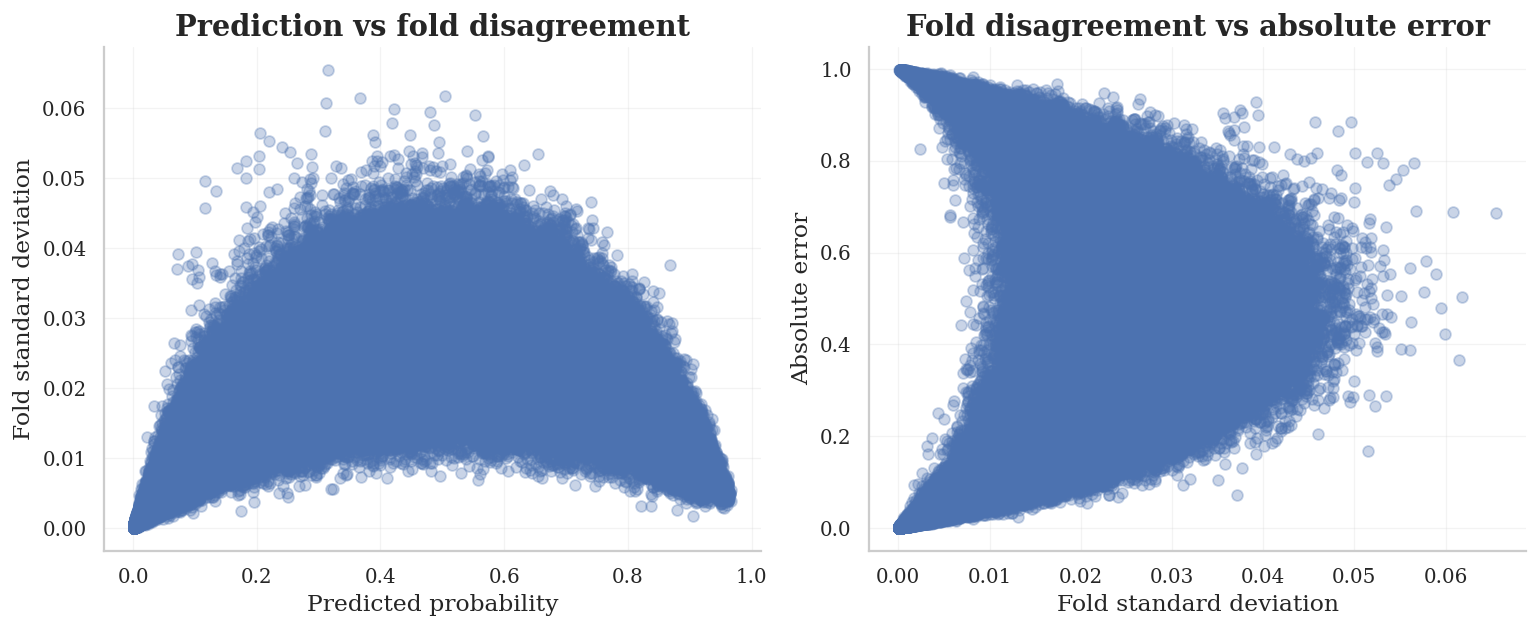

,mean_pred,observed_rate,mean_abs_error,n
fold_std,,,,
"(-0.0009382, 0.000666]",0.003392,0.001750,0.005128,118839
"(0.000666, 0.00317]",0.012918,0.011335,0.023767,118839
"(0.00317, 0.0136]",0.147528,0.151021,0.138210,118838
"(0.0136, 0.0233]",0.411039,0.442700,0.354451,118839
"(0.0233, 0.0656]",0.474269,0.519232,0.449057,118839


In [30]:
# full train-side member prediction matrix across all fold models
train_member_out = predict_realmlp_from_arrays(
    realmlp_bundle["X_num"].astype(np.float32),
    realmlp_bundle["X_cat"].astype(np.int64),
    realmlp_bundle,
    fold_cache,
    eval_bs=32768,
)

oof_fold_pred = train_member_out["member_preds"]

analysis_train["fold_std"] = oof_fold_pred.std(axis=1)
analysis_train["fold_range"] = oof_fold_pred.max(axis=1) - oof_fold_pred.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(analysis_train["realmlp_pred"], analysis_train["fold_std"], alpha=0.3)
axes[0].set_title("Prediction vs fold disagreement")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Fold standard deviation")

axes[1].scatter(analysis_train["fold_std"], analysis_train["abs_error"], alpha=0.3)
axes[1].set_title("Fold disagreement vs absolute error")
axes[1].set_xlabel("Fold standard deviation")
axes[1].set_ylabel("Absolute error")

plt.tight_layout()
savefig(cfg, "realmlp_05_disagreement_vs_error.png")
plt.show()

uncertainty_summary = analysis_train.groupby(
    pd.qcut(analysis_train["fold_std"], q=5, duplicates="drop")
).agg(
    mean_pred=("realmlp_pred", "mean"),
    observed_rate=("y_true", "mean"),
    mean_abs_error=("abs_error", "mean"),
    n=("y_true", "size"),
)
display(uncertainty_summary)

## 11. Local case studies

We create representative local diagnostics for:
- extreme TP,
- extreme TN,
- high-confidence FP,
- low-score FN.

For the neural model, the most honest local explanation is a local perturbation report:
- base prediction,
- top finite-difference sensitivities for numerical variables,
- effect of grouped categorical ablations for that row.


In [32]:
def local_numeric_sensitivity_for_row_arrays(
    row_index,
    realmlp_bundle,
    fold_cache,
    features,
    n_top=12,
    eval_bs=32768,
):
    X_num_full = realmlp_bundle["X_num"].astype(np.float32)
    X_cat_full = realmlp_bundle["X_cat"].astype(np.int64)
    feature_names = list(realmlp_bundle["NUMS"])
    feat_to_idx = {f: i for i, f in enumerate(feature_names)}

    valid_features = [f for f in features if f in feat_to_idx]

    X_num_row = X_num_full[[row_index]].copy()
    X_cat_row = X_cat_full[[row_index]].copy()

    base = predict_realmlp_from_arrays(
        X_num_row,
        X_cat_row,
        realmlp_bundle,
        fold_cache,
        eval_bs=eval_bs,
    )["mean_pred"][0]

    rows = []
    for feat in valid_features:
        j = feat_to_idx[feat]

        col_all = X_num_full[:, j].astype(np.float64)
        step = max(float(np.std(col_all, ddof=0)) * 0.05, 1e-3)

        X_num_plus = X_num_row.copy()
        X_num_minus = X_num_row.copy()
        X_num_plus[0, j] = X_num_plus[0, j] + step
        X_num_minus[0, j] = X_num_minus[0, j] - step

        p_plus = predict_realmlp_from_arrays(
            X_num_plus,
            X_cat_row,
            realmlp_bundle,
            fold_cache,
            eval_bs=eval_bs,
        )["mean_pred"][0]

        p_minus = predict_realmlp_from_arrays(
            X_num_minus,
            X_cat_row,
            realmlp_bundle,
            fold_cache,
            eval_bs=eval_bs,
        )["mean_pred"][0]

        sens = (p_plus - p_minus) / (2.0 * step)

        rows.append({
            "feature": feat,
            "local_abs_sensitivity": float(abs(sens)),
            "local_signed_sensitivity": float(sens),
            "step": float(step),
            "base_value": float(X_num_row[0, j]),
        })

    out = (
        pd.DataFrame(rows)
        .sort_values("local_abs_sensitivity", ascending=False)
        .head(n_top)
        .reset_index(drop=True)
    )
    return base, out


candidate_rows = []
for q in [
    analysis_train.query("case_type == 'TP'").sort_values("realmlp_pred", ascending=False),
    analysis_train.query("case_type == 'TN'").sort_values("realmlp_pred", ascending=True),
    analysis_train.query("case_type == 'FP'").sort_values("realmlp_pred", ascending=False),
    analysis_train.query("case_type == 'FN'").sort_values("realmlp_pred", ascending=True),
]:
    if len(q):
        candidate_rows.append(int(q.index[0]))

for ridx in candidate_rows:
    base_pred, local_sens = local_numeric_sensitivity_for_row_arrays(
        row_index=ridx,
        realmlp_bundle=realmlp_bundle,
        fold_cache=fold_cache,
        features=[f for f in ["tenure", "MonthlyCharges", "TotalCharges", "x1_0", "x1_1", "x2", "x3", "x4"]
                  if f in realmlp_bundle["NUMS"]],
        n_top=12,
        eval_bs=32768,
    )
    print({
        "row_index": ridx,
        "y_true": int(analysis_train.loc[ridx, "y_true"]),
        "pred": float(base_pred),
        "case_type": analysis_train.loc[ridx, "case_type"],
    })
    display(local_sens)

{'row_index': 213194, 'y_true': 1, 'pred': 0.9651018381118774, 'case_type': 'TP'}


,feature,local_abs_sensitivity,local_signed_sensitivity,step,base_value
0,x3,2.148020e-02,-2.148020e-02,0.016756,1.000001
1,x2,4.050195e-04,4.050195e-04,1.998573,95.449905
2,x1_0,2.104229e-04,2.104229e-04,0.011330,1.000000
3,x1_1,5.520270e-05,-5.520270e-05,1.255739,1.000000
4,tenure,5.156148e-05,-5.156148e-05,1.253095,1.000000
5,MonthlyCharges,2.183319e-05,2.183319e-05,1.553371,95.449997
6,x4,3.045480e-07,-3.045480e-07,96.291824,1.000000
7,TotalCharges,1.878855e-07,-1.878855e-07,117.695736,95.449997


{'row_index': 284352, 'y_true': 0, 'pred': 0.0013824042398482561, 'case_type': 'TN'}


,feature,local_abs_sensitivity,local_signed_sensitivity,step,base_value
0,x3,7.110491e-04,-7.110491e-04,0.016756,1.066182
1,x1_0,1.442137e-04,-1.442137e-04,0.011330,0.017770
2,x2,6.622617e-06,6.622617e-06,1.998573,61.434166
3,x1_1,5.725560e-07,5.725560e-07,1.255739,56.275570
4,tenure,4.450481e-07,4.450481e-07,1.253095,60.000000
5,MonthlyCharges,3.327499e-07,-3.327499e-07,1.553371,65.500000
6,x4,5.425983e-08,-5.425983e-08,96.291824,3600.000000
7,TotalCharges,3.971172e-08,-3.971172e-08,117.695736,3686.050049


{'row_index': 106705, 'y_true': 0, 'pred': 0.9608534574508667, 'case_type': 'FP'}


,feature,local_abs_sensitivity,local_signed_sensitivity,step,base_value
0,x3,3.271386e-02,-3.271386e-02,0.016756,1.004212
1,x2,4.718989e-04,4.718989e-04,1.998573,94.999908
2,x1_0,2.262046e-04,2.262046e-04,0.011330,1.004210
3,x1_1,6.467212e-05,-6.467212e-05,1.255739,0.995807
4,tenure,6.240651e-05,-6.240651e-05,1.253095,1.000000
5,MonthlyCharges,2.488370e-05,2.488370e-05,1.553371,95.400002
6,x4,3.549965e-07,-3.549965e-07,96.291824,1.000000
7,TotalCharges,2.271338e-07,-2.271338e-07,117.695736,95.000000


{'row_index': 81118, 'y_true': 1, 'pred': 0.0022984042298048735, 'case_type': 'FN'}


,feature,local_abs_sensitivity,local_signed_sensitivity,step,base_value
0,x3,1.687360e-03,-1.687360e-03,0.016756,0.911324
1,x1_0,9.612771e-04,-9.612771e-04,0.011330,0.023982
2,x2,8.716414e-06,8.716414e-06,1.998573,22.494736
3,MonthlyCharges,3.982057e-06,3.982057e-06,1.553371,20.500000
4,x1_1,1.440753e-06,1.440753e-06,1.255739,41.697559
5,tenure,2.005759e-07,2.005759e-07,1.253095,38.000000
6,TotalCharges,7.149267e-08,7.149267e-08,117.695736,854.799988
7,x4,5.960294e-09,5.960294e-09,96.291824,1444.000000


## 12. Export tables

This section writes the central report artefacts for the RealMLP study.

In [34]:
outdir = Path(cfg.output_dir)

analysis_train.to_csv(outdir / "realmlp_analysis_train.csv", index=False)
analysis_test.to_csv(outdir / "realmlp_analysis_test.csv", index=False)
replay["realmlp_fold_metrics_df"].to_csv(outdir / "realmlp_fold_metrics.csv", index=False)
replay["schema_df"].to_csv(outdir / "realmlp_schema_check.csv", index=False)
dec_realmlp.to_csv(outdir / "realmlp_deciles.csv", index=False)
perm_imp.to_csv(outdir / "realmlp_permutation_importance.csv", index=False)
sens_df.to_csv(outdir / "realmlp_finite_difference_sensitivity.csv", index=False)
ablation_df.to_csv(outdir / "realmlp_grouped_ablation.csv", index=False)
uncertainty_summary.to_csv(outdir / "realmlp_uncertainty_summary.csv")

summary = {
    "oof_auc": float(replay["realmlp_oof_auc"]),
    "oof_logloss": float(log_loss(bundle["y"], replay["realmlp_oof"])),
    "oof_brier": float(brier_score_loss(bundle["y"], replay["realmlp_oof"])),
    "n_numeric_features": int(schema["numeric_count"]),
    "n_categorical_features": int(schema["categorical_count"]),
    "top10_permutation_importance": perm_imp.head(10).set_index("feature")["mean_importance"].to_dict(),
    "top10_finite_difference_sensitivity": sens_df.head(10).set_index("feature")["mean_abs_sensitivity"].to_dict(),
}
(outdir / "realmlp_xai_summary.json").write_text(json.dumps(summary, indent=2))
summary


{'oof_auc': 0.9171993209286087,
 'oof_logloss': 0.29869582337069117,
 'oof_brier': 0.0955834612250328,
 'n_numeric_features': 22,
 'n_categorical_features': 54,
 'top10_permutation_importance': {'x2': 0.0056478004188659225,
  'SeniorCitizen': 0.0013062768447774653,
  'x1_0': 0.00098563323021994,
  'x3': 0.0005300559637209101,
  'tenure_digit1': 0.00031854286668386855,
  'MonthlyCharges': 0.00020172727197842466,
  'TotalCharges': 0.00019811209607401015,
  'TotalCharges_digit2': 0.00018454198728912186,
  'MonthlyCharges_digit2': 6.568548744279035e-05,
  'TotalCharges_digit3': 5.456684662719091e-05},
 'top10_finite_difference_sensitivity': {'x1_0': 0.1098923310637474,
  'SeniorCitizen': 0.022135356441140175,
  'MonthlyCharges_digit2': 0.003959360998123884,
  'tenure_digit1': 0.0025660244282335043,
  'x2': 0.0012736959615722299,
  'TotalCharges_digit2': 0.0011614697286859155,
  'TotalCharges_digit3': 0.0006937597063370049,
  'TotalCharges_digit1': 0.000672676251269877,
  'MonthlyCharges_di